# 01. Exploracion del conjunto HMS

Este notebook analiza exclusivamente el conjunto de desarrollo de la competencia HMS. Antes de calcular estadisticas, reserva pacientes completos para una evaluacion final interna. La particion reservada no se inspecciona ni se usa para tomar decisiones.

## Protocolo de evaluacion

- La unidad de agrupacion es `patient_id`; un paciente no puede aparecer en desarrollo y en el holdout.
- El holdout se define una vez, con semilla fija, y queda fuera del EDA y del ajuste de modelos.
- No se carga ni analiza `test.csv`, `test_eegs` ni `test_spectrograms`.
- Las etiquetas son votos de especialistas; se conservan como distribuciones objetivo, no solo como una clase dura.
- Ejecutar este notebook primero. Escribe `data/processed/split_manifest.json`, consumido por el notebook 02.

## Fuente de datos

Descargar la competencia HMS de Kaggle y extraerla en `data/`. Este notebook lee `data/train.csv`; la preparacion de espectrogramas usa `data/train_spectrograms/`. Los datos crudos no se versionan.

## Contenido

1. Configuracion y carga de dependencias
2. Particion por paciente antes de explorar
3. Auditoria del conjunto de desarrollo
4. Distribucion de votos y consenso
5. Cobertura por paciente y EEG
6. Valores faltantes y consistencia
7. Correlaciones de votos
8. Hallazgos y limitaciones

Responsable de este avance: Jordani Mejia.

## Preguntas del EDA

- Que clases concentran los votos y cuanta incertidumbre hay entre evaluadores?
- Hay pacientes con muchos segmentos que deban mantenerse agrupados?
- Que faltantes o inconsistencias requieren tratamiento antes de modelar?
- Que limitaciones impone usar espectrogramas precomputados frente a recalcularlos desde EEG crudo?

Las filas de HMS pueden compartir EEG y paciente, y varias etiquetas son ambiguas. No eliminar filas repetidas ni convertir los votos en una etiqueta unica sin justificarlo.

## 1. Configuracion y carga de metadatos

Solo se necesitan las etiquetas y los identificadores para este EDA. Los parquet de EEG/espectrogramas completos pueden ocupar decenas de GB y se consultaran de forma selectiva en la fase de preparacion.

In [1]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import GroupShuffleSplit

RANDOM_STATE = 42
HOLDOUT_SIZE = 0.20
VOTE_COLUMNS = [
    "seizure_vote",
    "lpd_vote",
    "gpd_vote",
    "lrda_vote",
    "grda_vote",
    "other_vote",
]


def find_project_root(start: Path = Path.cwd()) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "data").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("No se encontro la raiz del proyecto con las carpetas data/ y notebooks/.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
TRAIN_CSV_CANDIDATES = [
    DATA_DIR / "train.csv",
    DATA_DIR / "raw" / "hms" / "train.csv",
    DATA_DIR / "raw" / "train.csv",
]
TRAIN_CSV_PATH = next((path for path in TRAIN_CSV_CANDIDATES if path.is_file()), None)
if TRAIN_CSV_PATH is None:
    expected_paths = ", ".join(str(path) for path in TRAIN_CSV_CANDIDATES)
    raise FileNotFoundError(f"No se encontro train.csv. Rutas revisadas: {expected_paths}")

REQUIRED_COLUMNS = {
    "eeg_id",
    "eeg_sub_id",
    "eeg_label_offset_seconds",
    "spectrogram_id",
    "spectrogram_sub_id",
    "spectrogram_label_offset_seconds",
    "label_id",
    "patient_id",
    "expert_consensus",
    *VOTE_COLUMNS,
}
metadata = pd.read_csv(TRAIN_CSV_PATH, usecols=lambda column: column in REQUIRED_COLUMNS)
missing_columns = REQUIRED_COLUMNS.difference(metadata.columns)
if missing_columns:
    raise ValueError(f"Faltan columnas HMS requeridas: {sorted(missing_columns)}")
if metadata["patient_id"].isna().any():
    raise ValueError("patient_id contiene faltantes; no es posible garantizar una particion por paciente.")

print(f"Archivo de etiquetas: {TRAIN_CSV_PATH.relative_to(PROJECT_ROOT)}")
print(f"Filas etiquetadas: {len(metadata):,}")
print(f"Pacientes unicos: {metadata['patient_id'].nunique():,}")

Archivo de etiquetas: data\train.csv
Filas etiquetadas: 106,800
Pacientes unicos: 1,950


## 2. Reservar el holdout por paciente antes del EDA

Se reserva el 20% de los pacientes del conjunto etiquetado con una semilla fija. No se calculan estadisticas ni graficos para esa particion. El manifiesto local permite que los notebooks posteriores reconstruyan exactamente la misma separacion sin compartir el estado del kernel.

In [11]:
splitter = GroupShuffleSplit(n_splits=1, test_size=HOLDOUT_SIZE, random_state=RANDOM_STATE)
development_indices, holdout_indices = next(
    splitter.split(metadata, groups=metadata["patient_id"].astype(str))
)
development_metadata = metadata.iloc[development_indices].copy().reset_index(drop=True)
development_patient_ids = sorted(development_metadata["patient_id"].astype(str).unique().tolist())
holdout_patient_ids = sorted(metadata.iloc[holdout_indices]["patient_id"].astype(str).unique().tolist())

assert set(development_patient_ids).isdisjoint(holdout_patient_ids)
assert len(development_metadata) > 0

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
SPLIT_MANIFEST_PATH = PROCESSED_DATA_DIR / "split_manifest.json"
split_manifest = {
    "source": "HMS train.csv",
    "random_state": RANDOM_STATE,
    "holdout_size": HOLDOUT_SIZE,
    "group_column": "patient_id",
    "development_patient_ids": development_patient_ids,
    "holdout_patient_ids": holdout_patient_ids,
}
with SPLIT_MANIFEST_PATH.open("w", encoding="utf-8") as manifest_file:
    json.dump(split_manifest, manifest_file, indent=2)

print(f"Pacientes en desarrollo: {len(development_patient_ids):,}")
print(f"Filas disponibles para EDA: {len(development_metadata):,}")
print("Holdout final: reservado y no inspeccionado")
print(f"Manifiesto de particion: {SPLIT_MANIFEST_PATH.relative_to(PROJECT_ROOT)}")

Pacientes en desarrollo: 1,560
Filas disponibles para EDA: 84,131
Holdout final: reservado y no inspeccionado
Manifiesto de particion: data\processed\split_manifest.json


## 3. Inspeccion y calidad del conjunto de desarrollo

In [12]:
print("Dimensiones del conjunto de desarrollo:", development_metadata.shape)
display(development_metadata.head())

data_audit = pd.DataFrame({
    "dtype": development_metadata.dtypes.astype(str),
    "missing": development_metadata.isna().sum(),
    "unique": development_metadata.nunique(dropna=False),
})
display(data_audit)

if development_metadata[VOTE_COLUMNS].isna().any().any():
    raise ValueError("Hay votos faltantes en desarrollo; no se deben interpretar como cero.")
vote_matrix = development_metadata[VOTE_COLUMNS].astype(float)
row_vote_totals = vote_matrix.sum(axis=1)
zero_vote_rows = int(row_vote_totals.eq(0).sum())
if zero_vote_rows:
    print(f"Filas de desarrollo sin votos: {zero_vote_rows:,}; excluirlas del entrenamiento y documentar el criterio.")
else:
    print("Todas las filas de desarrollo tienen al menos un voto.")

print("Filas exactamente duplicadas en los campos cargados:", int(development_metadata.duplicated().sum()))
print("EEG con varios segmentos etiquetados:", int(development_metadata["eeg_id"].duplicated().sum()))
print("Registros por paciente:")
display(development_metadata.groupby("patient_id").size().describe().to_frame("rows_per_patient"))

Dimensiones del conjunto de desarrollo: (84131, 15)


,eeg_id,eeg_sub_id,eeg_label_offset_seconds,spectrogram_id,spectrogram_sub_id,spectrogram_label_offset_seconds,label_id,patient_id,expert_consensus,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote
0,1628180742,0,0.0,353733,0,0.0,127492639,42516,Seizure,3,0,0,0,0,0
1,1628180742,1,6.0,353733,1,6.0,3887563113,42516,Seizure,3,0,0,0,0,0
2,1628180742,2,8.0,353733,2,8.0,1142670488,42516,Seizure,3,0,0,0,0,0
3,1628180742,3,18.0,353733,3,18.0,2718991173,42516,Seizure,3,0,0,0,0,0
4,1628180742,4,24.0,353733,4,24.0,3080632009,42516,Seizure,3,0,0,0,0,0


,dtype,missing,unique
eeg_id,int64,0,13143
eeg_sub_id,int64,0,743
eeg_label_offset_seconds,float64,0,1475
spectrogram_id,int64,0,8740
spectrogram_sub_id,int64,0,1022
spectrogram_label_offset_seconds,float64,0,4420
label_id,int64,0,84131
patient_id,int64,0,1560
expert_consensus,str,0,6
seizure_vote,int64,0,18


Todas las filas de desarrollo tienen al menos un voto.
Filas exactamente duplicadas en los campos cargados: 0
EEG con varios segmentos etiquetados: 70988
Registros por paciente:


,rows_per_patient
count,1560.000000
mean,53.930128
std,134.695207
min,1.000000
25%,8.000000
50%,19.000000
75%,46.000000
max,2215.000000


## 4. Distribucion de clases e incertidumbre de anotacion

La competencia proporciona conteos de votos por clase. Para el entrenamiento se conservara la distribucion normalizada de esos votos como objetivo probabilistico; `expert_consensus` se utiliza aqui solo para describir el consenso mayoritario.

,class,vote_count,vote_share
0,OTHER,168456.0,0.275575
1,GPD,106106.0,0.173577
2,LPD,96179.0,0.157338
3,GRDA,87689.0,0.143449
4,SEIZURE,76514.0,0.125168
5,LRDA,76346.0,0.124893


Consensus labels in development:


,rows
expert_consensus,
Seizure,16766
Other,14806
GRDA,14487
GPD,13267
LRDA,12882
LPD,11923


Maximum class-vote share per row:


,max_vote_share
count,84131.000000
mean,0.811528
std,0.211145
min,0.200000
25%,0.666667
50%,0.923077
75%,1.000000
max,1.000000


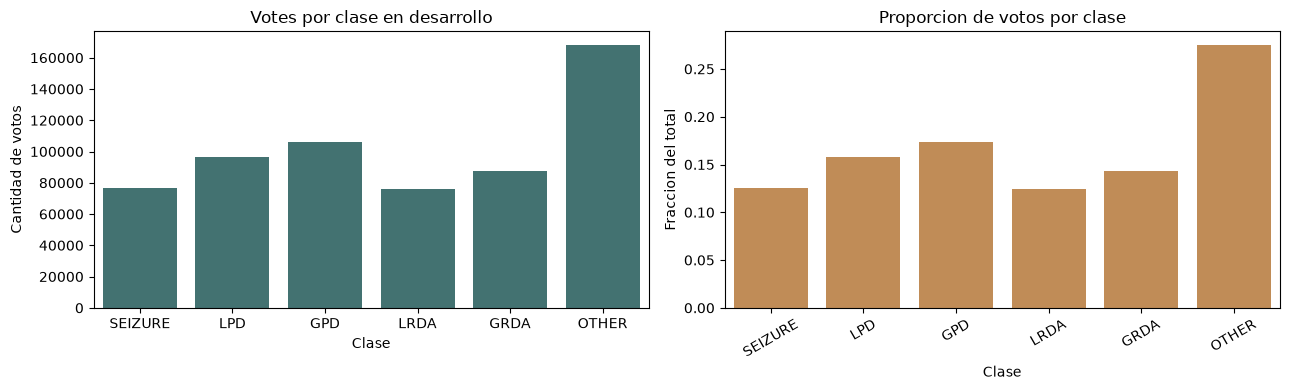

In [7]:
CLASS_NAMES = [column[:-5].upper() for column in VOTE_COLUMNS]
class_vote_totals = vote_matrix.sum(axis=0)
class_vote_share = class_vote_totals / class_vote_totals.sum()
maximum_vote_share = vote_matrix.div(row_vote_totals.replace(0, np.nan), axis=0).max(axis=1)

class_summary = pd.DataFrame({
    "class": CLASS_NAMES,
    "vote_count": class_vote_totals.to_numpy(),
    "vote_share": class_vote_share.to_numpy(),
})
display(class_summary.sort_values("vote_count", ascending=False).reset_index(drop=True))
print("Consensus labels in development:")
display(development_metadata["expert_consensus"].value_counts(dropna=False).to_frame("rows"))
print("Maximum class-vote share per row:")
display(maximum_vote_share.describe().to_frame("max_vote_share"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=class_summary, x="class", y="vote_count", ax=axes[0], color="#3B7A78")
axes[0].set_title("Votes por clase en desarrollo")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Cantidad de votos")
sns.barplot(data=class_summary, x="class", y="vote_share", ax=axes[1], color="#D28C45")
axes[1].set_title("Proporcion de votos por clase")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Fraccion del total")
axes[1].tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

## 5. Faltantes, redundancia e informacion temporal

El archivo de etiquetas no incluye fechas de adquisicion, por lo que no se infieren tendencias temporales. En desarrollo no se encontraron valores faltantes en los campos cargados ni filas exactamente duplicadas. Hay 8.439 EEG con mas de un segmento etiquetado; `eeg_sub_id`, offsets y `label_id` distinguen esos segmentos, por lo que no deben eliminarse como duplicados. Ningun EEG aparece asociado a mas de un paciente.

,missing_rows


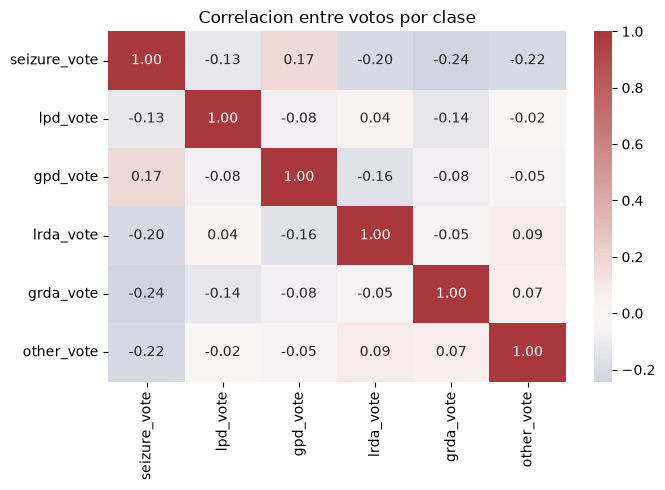

EEG representados por mas de una fila: 8439
EEG asociados a mas de un paciente: 0


In [13]:
missing_by_column = development_metadata.isna().sum().sort_values(ascending=False)
display(missing_by_column[missing_by_column.gt(0)].to_frame("missing_rows"))

vote_correlations = vote_matrix.corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(vote_correlations, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Correlacion entre votos por clase")
fig.tight_layout()
plt.show()

duplicate_eeg_summary = development_metadata.groupby("eeg_id").agg(
    rows=("eeg_id", "size"),
    patients=("patient_id", "nunique"),
    spectrograms=("spectrogram_id", "nunique"),
)
print("EEG representados por mas de una fila:", int(duplicate_eeg_summary["rows"].gt(1).sum()))
print("EEG asociados a mas de un paciente:", int(duplicate_eeg_summary["patients"].gt(1).sum()))

## 6. Hallazgos y decisiones metodologicas

Hallazgos sobre el conjunto de desarrollo generado con semilla 42:

- Se analizaron 84.131 segmentos de 1.560 pacientes; el CSV completo contiene 106.800 segmentos de 1.950 pacientes. El holdout por paciente permanece reservado.
- No se encontraron faltantes en las columnas cargadas, filas sin votos ni filas exactamente duplicadas cuando se incluyen `label_id`, sub-ID y offsets.
- 8.439 EEG tienen mas de un segmento etiquetado; los EEG no se comparten entre pacientes.
- La fraccion de votos por clase fue: Other 27,6%, GPD 17,4%, LPD 15,7%, GRDA 14,3%, Seizure 12,5% y LRDA 12,5%.
- La proporcion media de votos de la clase mas votada por segmento fue 81,2% (mediana 92,3%); conservar el vector de seis votos mantiene la incertidumbre de los casos discutidos.

Decisiones para las siguientes fases:

- Mantener el split por paciente y los folds `StratifiedGroupKFold`; no usar el holdout para explorar ni seleccionar modelos.
- Usar las seis proporciones de votos como objetivo probabilistico; el consenso experto solo es descriptivo o auxiliar para estratificar.
- Consumir los espectrogramas oficiales precomputados como imagenes; este notebook no recalcula STFT desde EEG crudo.
- No se reportan metricas predictivas ni conclusiones clinicas: aun falta entrenar y evaluar modelos.
